![header](https://i.imgur.com/I4ake6d.jpg)


# COPERNICUS MARINE SERVICE : Arctic Ocean

<div style="text-align: right"><i> Lesson 2 of 3 - Copernicus Marine Toolbox </i></div>

***
<center><h1> Atlantic Water in the Fram Strait: extracting data with subset </h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>
<br>
**General Note 3**: Exercises are shown in yellow boxes. Write your answer in the empty cell below each exercise. If you are stuck, a solution can be loaded from the `_solved` folder.<br>
***

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
    - [2.2 Checking the environment](#2.2-Checking-the-environment)
- [3. Choosing the data on the Data Store](#3.-Choosing-the-data-on-the-Data-Store)
    - [3.1 The Help Center and the Data Store](#3.1-The-Help-Center-and-the-Data-Store)
    - [3.2 Presentation of the product used](#3.2-Presentation-of-the-product-used)
    - [3.3 Building a request with the Subsetter](#3.3-Building-a-request-with-the-Subsetter)
- [4. Extracting data with subset](#4.-Extracting-data-with-subset)
    - [4.1 Logging in](#4.1-Logging-in)
    - [4.2 Checking a request before running it](#4.2-Checking-a-request-before-running-it)
    - [4.3 Exploring the object returned by subset](#4.3-Exploring-the-object-returned-by-subset)
    - [4.4 Downloading the data](#4.4-Downloading-the-data)
- [5. First look at the data with xarray](#5.-First-look-at-the-data-with-xarray)
    - [5.1 Opening the file](#5.1-Opening-the-file)
    - [5.2 A map of the Atlantic Water](#5.2-A-map-of-the-Atlantic-Water)
    - [5.3 A section across the Fram Strait](#5.3-A-section-across-the-Fram-Strait)
- [6. Exercises to go further](#6.-Exercises-to-go-further)
- [7. Conclusion](#7.-Conclusion)

---
# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The **Fram Strait**, between Greenland and Svalbard, is the only deep passage between the Arctic Ocean (see [Wikipedia - Fram Strait](https://en.wikipedia.org/wiki/Fram_Strait#cite_note-1)) and the rest of the world ocean. Two currents flow through it in opposite directions:

- on the eastern side, along Svalbard, the **West Spitsbergen Current** carries warm and salty **Atlantic Water** northward, into the Arctic Ocean
- on the western side, along Greenland, the **East Greenland Current** carries cold and fresher polar water, and most of the sea ice leaving the Arctic, southward

The heat brought by the Atlantic Water is one of the reasons why the sea ice is getting thinner in parts of the Arctic: scientists call the growing influence of these waters the **"Atlantification"** of the Arctic Ocean ([Yale e360 article](https://e360.yale.edu/digest/arctic-ocean-undergoing-atlantification-scientists-say)). Since this water flows below the surface, satellites cannot see it: we need ocean models that combine physics and in-situ observations.

| | |
| :--- | :--- |
| **Objective** | Learn how to extract only the part of a dataset you need, for a given area, period, depth range and set of variables, with the `subset` function of the Copernicus Marine Toolbox. |
| **Main question** | Where, and at which depths, does the warm Atlantic Water cross the Fram Strait? |
| **Expected outcomes** | You will be able to build a request on the Data Store, check its size before running it, explore the object returned by the Toolbox, download the data, and map them and draw a vertical section with xarray. |
| **Duration** | About 30 minutes |
| **Prerequisites** | A free [Copernicus Marine account](https://data.marine.copernicus.eu/register) and basic Python knowledge |

This notebook is the second of a series of three. The first one presents the `get` function, and the last one the `open_dataset` and `read_dataframe` functions. Each notebook can be followed on its own.

---
# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

## 2.1 Required Python modules

[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this notebook.

| Module name | Description |
| :---: | :---|
| **copernicusmarine** | The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) gives access to the Copernicus Marine catalogue and data from Python or from the command line. |
| **xarray** | [Xarray](https://docs.xarray.dev/en/stable/) is a very user-friendly library to manipulate NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays. |
| **matplotlib** | [Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** | [Cartopy](https://scitools.org.uk/cartopy/docs/latest/) is a library for plotting maps and geospatial data in Python. |
| **pathlib** | [Pathlib](https://docs.python.org/3/library/pathlib.html) handles file paths in the same way on every operating system. |

We also import a small plotting function, `plot_arctic_map`, stored in the `utils` folder. It draws a map centred on the North Pole, so that the map code is not repeated in every cell. You can open `utils/arctic_maps.py` to see how it works.

In [1]:
# To avoid warning messages
import warnings
warnings.filterwarnings("ignore")

# Import libraries
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr

from utils.arctic_maps import plot_arctic_map

## 2.2 Checking the environment

[Go back to the "Table of contents"](#Table-of-contents)

Let's check the versions of the main packages. This notebook was written for **version 2.5.0** of the Copernicus Marine Toolbox: if your version is older, see the [installation guide](https://help.marine.copernicus.eu/en/articles/7970514-copernicus-marine-toolbox-installation) to update it.

In [3]:
for package in ["copernicusmarine", "xarray", "matplotlib", "cartopy"]:
    print(f"{package:<18} {version(package)}")

copernicusmarine   2.5.0b0
xarray             2026.7.0
matplotlib         3.11.1
cartopy            0.25.0


We also create the folder where the downloaded files will be stored:

In [7]:
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)
print(f"Files will be downloaded to: {data_directory.resolve()}")

Files will be downloaded to: /homelocal/gkoenig/Downloads/Training_Toolbox/data


## 2.3 Copernicus Marine Toolbox
[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Toolbox](https://help.marine.copernicus.eu/en/articles/7949409-copernicus-marine-toolbox-introduction) is a library that gives access to the Copernicus Marine data from Python code or from the command line.

To import it, we use:

In [5]:
import copernicusmarine

And then we have to log in.

The **login** function asks for the username and password of your Copernicus Marine account. It saves them in a configuration file, so that you do not need to enter them again in the next cells, or in the next notebooks of this training.

If you do not have an account yet, you can create one for free on the [registration page](https://data.marine.copernicus.eu/register).

In [6]:
copernicusmarine.login()

INFO - 2026-10-08T13:21:25Z - Using existing credentials from /homelocal/gkoenig/.copernicusmarine/.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

> 📖 **Learn more in the Help Center:** [Toolbox credentials configuration](https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration)

---
# 3. Choosing the data on the Data Store

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 The Help Center and the Data Store

[Go back to the "Table of contents"](#Table-of-contents)

The [Copernicus Marine Help Center](https://help.marine.copernicus.eu/) answers most questions about the Copernicus Marine products and tools. Throughout this notebook, the 📖 boxes point to the articles that go deeper into each topic. A good place to start is [How to access and download Copernicus Marine data](https://help.marine.copernicus.eu/en/articles/16733110-how-to-access-and-download-copernicus-marine-data).

The [Copernicus Marine Data Store](https://data.marine.copernicus.eu/products) lists all the products of the service. You can find a product with the filters ("Variables", "Areas", "Time range", or "Advanced" for more criteria) or by typing its name or ID in the search bar. Each product page has a **Description**, a **Data access** section listing its datasets, and a **Documentation** section with the Product User Manual (PUM) and the Quality Information Document (QUID).

> 📖 **Learn more in the Help Center:** [Introduction to the Data Store](https://help.marine.copernicus.eu/en/articles/6722477-introduction-to-the-copernicus-marine-data-store) · [How to search for a product](https://help.marine.copernicus.eu/en/articles/4425061-how-to-search-for-a-product-within-the-copernicus-marine-data-store) · [Products, datasets and their identifiers](https://help.marine.copernicus.eu/en/articles/4703373-differences-between-copernicus-marine-products-and-datasets-and-their-identifiers)

## 3.2 Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)

In this notebook, we use the product **Arctic Ocean Physics Reanalysis**, produced by the Nansen Environmental and Remote Sensing Center (NERSC, Norway) with the TOPAZ4 system. A **reanalysis** is a reconstruction of the past state of the ocean: an ocean model is run over several decades and regularly corrected with observations (satellites, temperature and salinity profiles), a technique called **data assimilation**. The result is a complete, consistent picture of the ocean, including at depths that satellites cannot see.

| Parameter | Value |
| :---: | :---|
| **Product ID** | [ARCTIC_MULTIYEAR_PHY_002_003](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_002_003/description) |
| **Dataset ID** | cmems_mod_arc_phy_my_topaz4_P1M (monthly means) |
| **Source** | Numerical model with data assimilation (reanalysis) |
| **Spatial resolution** | 0.125° (the model itself has a resolution of 11 to 16 km) |
| **Spatial coverage** | Arctic Ocean and North Atlantic, north of 50°N |
| **Depth levels** | 40, from the surface to 4000 m |
| **Temporal resolution** | Monthly means |
| **Temporal coverage** | From 1991 to a few months ago |
| **Variables used** | thetao (sea temperature, °C), so (salinity) |
| **DOI** | [10.48670/moi-00007](https://doi.org/10.48670/moi-00007) |

| <img src="https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/ARCTIC_MULTIYEAR_PHY_002_003.jpg" width="400"> |
|:--:|
| Arctic Ocean Physics Reanalysis. - From the [Copernicus Marine Data Store](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_002_003/description) |

**For information on how to use the product, please consult the User Manual:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-ARC-PUM-002-003.pdf)

**For information about the quality of the product, please consult the document:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-ARC-QUID-002-003.pdf)

> 📖 **Learn more in the Help Center:** [What is in the PUM?](https://help.marine.copernicus.eu/en/articles/4425095-what-kind-of-information-can-be-found-in-the-pum) · [What is in the QUID?](https://help.marine.copernicus.eu/en/articles/6588555-what-kind-of-information-can-be-found-in-the-quid) · [How to cite Copernicus Marine products](https://help.marine.copernicus.eu/en/articles/4444611-how-to-cite-copernicus-marine-products-and-services)

## 3.3 Building a request with the Subsetter

[Go back to the "Table of contents"](#Table-of-contents)

On the product page, open the **Data access** section and click on **Form** in the "Subset" column of the monthly dataset. The **Subsetter** lets you select:

- the **variables**
- the **area**, by typing the coordinates or by drawing a rectangle on the map with "Draw on map"
- the **time range**
- the **depth range**, for datasets with several depth levels

| <img src="img/02_subsetter_form.png" width="800"> |
|:--:|
| The Subsetter form, with the Fram Strait selected. |

You can download the data directly from the form, up to 800 MB. But the most useful button for us is **Automate**: it writes the equivalent Toolbox command, for the command line or for Python. It is the easiest way to build your first requests without typing any coordinates.

| <img src="img/02_automate.png" width="800"> |
|:--:|
| The "Automate" button gives the Python command corresponding to the selection. |

> 📖 **Learn more in the Help Center:** [Download data with the Subsetter form](https://help.marine.copernicus.eu/en/articles/8078281-how-to-download-copernicus-marine-data-with-the-graphical-user-interface-subset-form)

---
# 4. Extracting data with subset

[Go back to the "Table of contents"](#Table-of-contents)

The `get` function downloads the original files of a dataset, as delivered by the producer. The `subset` function works differently: it reads the data from a copy optimised for extraction, called **ARCO** (Analysis Ready, Cloud Optimised), and returns **only the part you ask for**. It is the best choice as soon as you need a region, a period, a few depth levels or a few variables, rather than whole files.

> 📖 **Learn more in the Help Center:** [Differences between original files and ARCO data](https://help.marine.copernicus.eu/en/articles/8656000-differences-between-original-producer-files-and-arco-data)

## 4.2 Checking a request before running it

[Go back to the "Table of contents"](#Table-of-contents)

Let's define our request: the temperature in the **Fram Strait**, in **August 2024**, from the **surface to 1000 m**. We store each parameter in a variable, so that we can reuse them in the next cells.

In [8]:
dataset_id = "cmems_mod_arc_phy_my_topaz4_P1M"

# Area: the Fram Strait, between Greenland (west) and Svalbard (east)
minimum_longitude, maximum_longitude = -20, 15
minimum_latitude, maximum_latitude = 77, 81

# Period: August 2024 (the dataset contains one monthly mean per month)
start_date, end_date = "2024-08-01", "2024-08-31"

# Depth: from the surface to 1000 m
minimum_depth, maximum_depth = 0, 1000

As with `get`, the `dry_run` option checks the request without downloading anything. It is a good habit to always start with it:

In [9]:
dry_run_response = copernicusmarine.subset(
    dataset_id=dataset_id,
    variables=["thetao"],
    minimum_longitude=minimum_longitude,
    maximum_longitude=maximum_longitude,
    minimum_latitude=minimum_latitude,
    maximum_latitude=maximum_latitude,
    start_datetime=start_date,
    end_datetime=end_date,
    minimum_depth=minimum_depth,
    maximum_depth=maximum_depth,
    dry_run=True,
)

WARNING - 2026-10-08T13:27:07Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T13:27:07Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T13:27:07Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T13:27:08Z - Selected dataset version: "202506"
INFO - 2026-10-08T13:27:08Z - Selected dataset part: "default"
INFO - 2026-10-08T13:27:09Z - Total size of the download: 1.11 MB.


In [10]:
print(f"Estimated file size: {dry_run_response.file_size:.1f} MB")
print(f"Data read on the server to build it: {dry_run_response.data_transfer_size:.1f} MB")

Estimated file size: 1.1 MB
Data read on the server to build it: 225.8 MB


Our file will only weigh about one megabyte. The second number is larger because the server stores the data in blocks, called **chunks**, and has to read whole chunks even when we only need part of them.

<div class="alert alert-block alert-warning">

**Exercise 1**

What would happen without any selection? Run a dry run for the variable `thetao` with **only** the dataset ID and the variable: no area, no period and no depth.

How large would the file be, and how many times larger than our Fram Strait selection?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Keep only the arguments `dataset_id`, `variables` and `dry_run` in the call. The size of our selection is stored in `dry_run_response.file_size`.
</details>

In [20]:
# Write you code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [14]:
# %load _solved/ARCTBX-02-subset_exercise-1.py


> 📖 **Learn more in the Help Center:** [Toolbox API - Subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset)

## 4.3 Exploring the object returned by subset

[Go back to the "Table of contents"](#Table-of-contents)

Like `get`, the `subset` function returns a Python object describing the result. Let's look at its type and content:

In [15]:
type(dry_run_response)

copernicusmarine.core_functions.models.ResponseSubset

In [16]:
dry_run_response

ResponseSubset(file_path=PosixPath('cmems_mod_arc_phy_my_topaz4_P1M_thetao_20.00W-15.00E_77.00N-81.00N_0.00-1000.00m_2024-08-01.nc'), output_directory=PosixPath('.'), filename='cmems_mod_arc_phy_my_topaz4_P1M_thetao_20.00W-15.00E_77.00N-81.00N_0.00-1000.00m_2024-08-01.nc', file_size=1.112828244274809, data_transfer_size=225.82717557251908, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=-20.0, maximum=15.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=77.0, maximum=81.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2024-08-01T00:00:00+00:00', maximum='2024-08-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.0, maximum=1000.0, unit='m', coordinate_id='depth')], status=<StatusCode.DRY_RUN: '001'>, message=<StatusMessage.DRY_RUN: 'The request was run with the dry-run option. No data was downloaded.'>, file_status='DOWNLOADED', file_names=None)

This `ResponseSubset` object contains, among others, the name of the file that will be created, the variables, and the estimated sizes we already used:

In [17]:
print(f"File name: {dry_run_response.filename}")
print(f"Variables: {dry_run_response.variables}")

File name: cmems_mod_arc_phy_my_topaz4_P1M_thetao_20.00W-15.00E_77.00N-81.00N_0.00-1000.00m_2024-08-01.nc
Variables: ['thetao']


Its `coordinates_extent` attribute is especially useful: it gives the **real bounds** of the data that will be returned, for each coordinate. Let's print them:

In [18]:
for extent in dry_run_response.coordinates_extent:
    print(f"{extent.coordinate_id:<10} from {extent.minimum} to {extent.maximum} ({extent.unit})")

longitude  from -20.0 to 15.0 (degrees_east)
latitude   from 77.0 to 81.0 (degrees_north)
time       from 2024-08-01T00:00:00+00:00 to 2024-08-01T00:00:00+00:00 (iso8601)
depth      from 0.0 to 1000.0 (m)


Here, the bounds match our request, because 0 and 1000 m are depth levels of the model and our longitudes and latitudes fall on grid points. This is not always the case: the dataset only has **40 depth levels**, for example 900 m, 1000 m, 1200 m and 1400 m. If you ask for a depth that is not a level, the `coordinates_selection_method` option decides what happens:

- `"inside"` (the default): only the values **inside** your range are returned
- `"outside"`: the range is extended to the next values **outside** it, so that your whole range is covered
- `"nearest"`: the values **nearest** to your bounds are returned
- `"strict-inside"`: like "inside", but an error is raised if the values do not exist

<div class="alert alert-block alert-warning">

**Exercise 2**

Run a dry run of the same request, but down to **1100 m**. Use `coordinates_extent` to find the deepest level that would be returned.

Then run it again with `coordinates_selection_method="outside"`. What changes?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the dry run cell above and replace `maximum_depth=maximum_depth` with `maximum_depth=1100`. In the loop over `coordinates_extent`, the depth is the extent whose `coordinate_id` is `"depth"`.
</details>

In [28]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [30]:
# %load _solved/ARCTBX-02-subset_exercise-2.py


## 4.4 Downloading the data

[Go back to the "Table of contents"](#Table-of-contents)

The request is small and correct: let's download it. We remove the `dry_run` option and add:

- `output_directory` to choose the folder where the file is saved
- `output_filename` to give the file a clear name
- `skip_existing=True` to avoid downloading the file again if it is already there. Without it, running the cell twice would create a second file called `..._(1).nc`

In [31]:
temperature_response = copernicusmarine.subset(
    dataset_id=dataset_id,
    variables=["thetao"],
    minimum_longitude=minimum_longitude,
    maximum_longitude=maximum_longitude,
    minimum_latitude=minimum_latitude,
    maximum_latitude=maximum_latitude,
    start_datetime=start_date,
    end_datetime=end_date,
    minimum_depth=minimum_depth,
    maximum_depth=maximum_depth,
    output_directory=data_directory,
    output_filename="fram_strait_temperature_2024-08.nc",
    skip_existing=True,
)

WARNING - 2026-10-08T13:42:47Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T13:42:47Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
WARNING - 2026-10-08T13:42:47Z - Using a pre-release or a non-official version of the client. Client version: 2.5.0b0
INFO - 2026-10-08T13:42:47Z - Selected dataset version: "202506"
INFO - 2026-10-08T13:42:47Z - Selected dataset part: "default"
100%|██████████| [00:07<00:00]
INFO - 2026-10-08T13:42:55Z - Total size of the download: 1.11 MB.


The returned object gives the path of the file. Let's check that the download worked:

In [32]:
temperature_file = Path(temperature_response.file_path)

print(f"File path: {temperature_file}")
print(f"The file exists: {temperature_file.exists()}")
print(f"Size on disk: {temperature_file.stat().st_size / 1e6:.1f} MB")

File path: data/fram_strait_temperature_2024-08.nc
The file exists: True
Size on disk: 1.2 MB


<div class="alert alert-block alert-warning">

**Exercise 3**

To know where the Atlantic Water is, oceanographers look at both temperature and **salinity**: Atlantic Water is warm, but also saltier than polar water.

Download the salinity (variable `so`) for the same area, period and depths, in a file called `fram_strait_salinity_2024-08.nc`.
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Copy the download cell above, then change the variable and the file name. Store the result in a new variable, for example `salinity_response`.
</details>

In [36]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [35]:
# %load _solved/ARCTBX-02-subset_exercise-3.py


> 📖 **Learn more in the Help Center:** [Toolbox API - Subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset) · [The same with the command line](https://help.marine.copernicus.eu/en/articles/7972861-copernicus-marine-toolbox-cli-subset) · [How to choose between NetCDF and Zarr](https://help.marine.copernicus.eu/en/articles/8176692-how-to-choose-between-netcdf-and-zarr-format-using-the-toolbox)

---
# 5. First look at the data with xarray

[Go back to the "Table of contents"](#Table-of-contents)

## 5.1 Opening the file

[Go back to the "Table of contents"](#Table-of-contents)

The file is in **NetCDF** format, a self-describing format for multi-dimensional scientific data. We open it with xarray:

In [37]:
temperature_data = xr.open_dataset(temperature_file)
temperature_data

<xarray.Dataset> Size: 1MB
Dimensions:    (time: 1, depth: 31, latitude: 33, longitude: 281)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-08-01
  * depth      (depth) float32 124B 0.0 2.0 4.0 6.0 ... 700.0 800.0 900.0 1e+03
  * latitude   (latitude) float64 264B 77.0 77.12 77.25 ... 80.75 80.88 81.0
  * longitude  (longitude) float64 2kB -20.0 -19.88 -19.75 ... 14.75 14.88 15.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 1MB ...
Attributes:
    Conventions:               CF-1.4
    field_date:                2024-12
    field_type:                Files based on file type nersc_weekly
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    references:                https://doi.org/10.48670/moi-00007
    source:                    NERSC-HYCOM model fields
    title:                     Arctic Ocean Physics Reanalysis, 12.5km monthl...
    copernicusmarine_version:  2.5.0b0

The dataset has **four dimensions**: time (a single month here), depth, latitude and longitude, and a single variable, `thetao`, the sea temperature in °C. Unlike the original files of the previous notebook, the file only contains what we asked for.

Let's select our single month and check the data. Missing values (`NaN`) correspond to land (Greenland and Svalbard) and to the depths that are below the sea floor:

In [38]:
# Select the single month, and sort the depths from the surface to the bottom
temperature = temperature_data["thetao"].isel(time=0).sortby("depth")

print(f"Depth levels (m): {temperature.depth.values}")

missing_points = int(temperature.isnull().sum())
print(f"Missing values: {missing_points} of {temperature.size} ({100 * missing_points / temperature.size:.0f}%)")
print(f"Temperature range: {float(temperature.min()):.1f}°C to {float(temperature.max()):.1f}°C")

Depth levels (m): [   0.    2.    4.    6.   10.   15.   20.   25.   30.   40.   50.   60.
   70.   80.   90.  100.  125.  150.  175.  200.  250.  300.  350.  400.
  450.  500.  600.  700.  800.  900. 1000.]
Missing values: 95197 of 287463 (33%)
Temperature range: -1.7°C to 9.9°C


## 5.2 A map of the Atlantic Water

[Go back to the "Table of contents"](#Table-of-contents)

The Atlantic Water flows below the surface layer, which is warmed by the sun in summer. Let's map the temperature at **200 m**. With `method="nearest"`, xarray selects the depth level closest to the one we ask for:

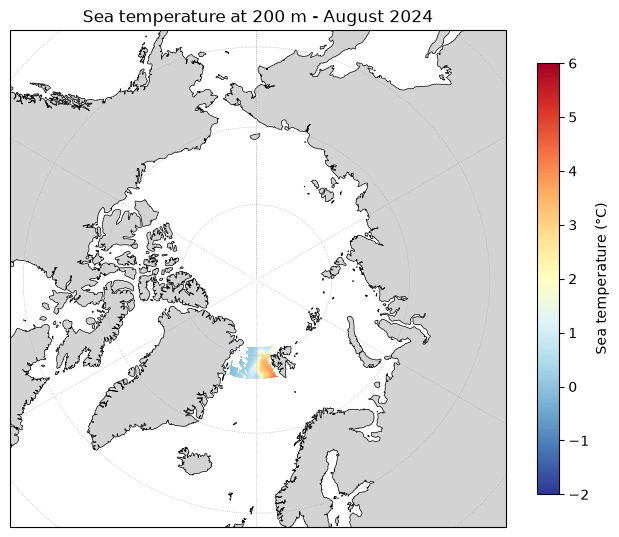

In [44]:
temperature_200m = temperature.sel(depth=200, method="nearest")

plot_arctic_map(
    temperature_200m,
    "Sea temperature at 200 m - August 2024",
    step=1,
    cmap="RdYlBu_r", vmin=-2, vmax=6,
    cbar_kwargs={"label": "Sea temperature (°C)", "shrink": 0.7},
)
plt.show()

The contrast between the two sides of the strait should stand out: water above 2°C along the west coast of Svalbard, carried north by the West Spitsbergen Current, and water close to the freezing point (around -1.8°C for sea water) on the Greenland side.

## 5.3 A section across the Fram Strait

[Go back to the "Table of contents"](#Table-of-contents)

To see at which depths the Atlantic Water flows, we can draw a **vertical section**: the temperature along a line crossing the strait, as a function of longitude and depth. We select the latitude 79°N, and draw the **2°C line**, a common threshold to identify Atlantic Water:

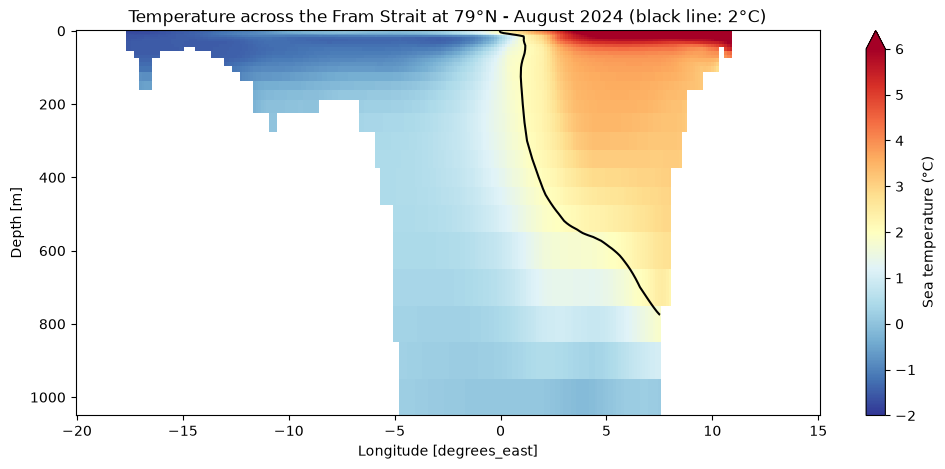

In [41]:
temperature_section = temperature.sel(latitude=79, method="nearest")

fig, ax = plt.subplots(figsize=(12, 5))
temperature_section.plot(
    ax=ax, y="depth", yincrease=False,
    cmap="RdYlBu_r", vmin=-2, vmax=6,
    cbar_kwargs={"label": "Sea temperature (°C)"},
)
temperature_section.plot.contour(ax=ax, y="depth", yincrease=False, levels=[2], colors="black")
ax.set_title("Temperature across the Fram Strait at 79°N - August 2024 (black line: 2°C)")
plt.show()

`yincrease=False` puts the surface at the top. The white areas at the bottom and on the sides are the sea floor and the continental shelves.

Xarray also makes computations easy. For example, let's compute the **mean temperature between 100 and 500 m** at each longitude, the layer where we expect the core of the Atlantic Water. `slice(100, 500)` selects all the depth levels between 100 and 500 m, and `.mean(dim="depth")` averages them:

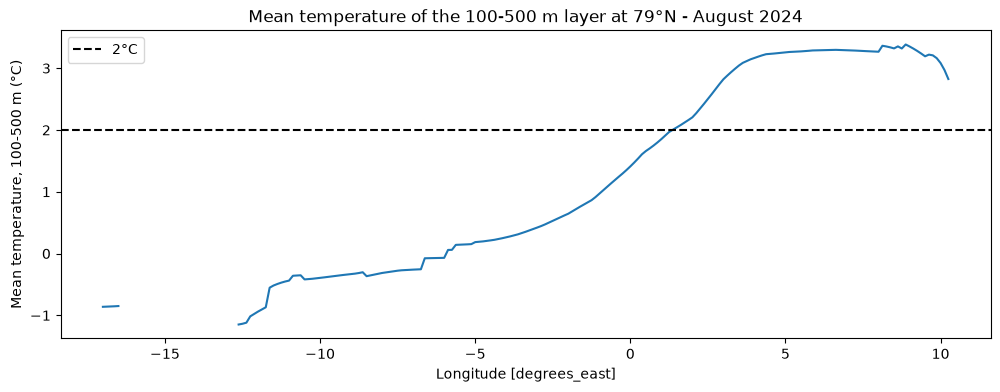

The warmest part of the layer is at 8.9°E, with 3.4°C


In [42]:
atlantic_layer = temperature_section.sel(depth=slice(100, 500)).mean(dim="depth")

atlantic_layer.plot(figsize=(12, 4))
plt.axhline(2, color="black", linestyle="--", label="2°C")
plt.ylabel("Mean temperature, 100-500 m (°C)")
plt.title("Mean temperature of the 100-500 m layer at 79°N - August 2024")
plt.legend()
plt.show()

warmest_longitude = float(atlantic_layer.idxmax())
print(f"The warmest part of the layer is at {warmest_longitude:.1f}°E, with {float(atlantic_layer.max()):.1f}°C")

The warm core sits on the eastern side of the strait, west of Svalbard: this is the West Spitsbergen Current bringing Atlantic heat into the Arctic Ocean.

<div class="alert alert-block alert-warning">

**Exercise 4**

Draw the same section at 79°N for the **salinity** you downloaded in exercise 3, with the **34.9 line**, the salinity threshold usually used for Atlantic Water.

Does the salty water match the warm water of the temperature section?
</div>

<details>
<summary><b>Hint</b> (click to expand)</summary>

Open the file with `xr.open_dataset(salinity_response.file_path)`, select the variable `so`, the single month with `.isel(time=0)` and sort the depths with `.sortby("depth")`, then reuse the section cell above. A colour scale from 32 to 35.2 works well, for example with `cmap="viridis"`.
</details>

In [ ]:
# Write your code here

**Solution:** remove the `#` at the beginning of the next cell and run it. The first run loads the solution into the cell, the second run executes it.

In [ ]:
# %load _solved/ARCTBX-02-subset_exercise-4.py

> 📖 **Learn more in the Help Center:** [How to open and visualize Copernicus Marine data using Python](https://help.marine.copernicus.eu/en/articles/4854800-how-to-open-and-visualize-copernicus-marine-data-using-python)

---
# 6. Exercises to go further

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-info">

Here is a set of exercises to go further. There are two levels, depending on how much Python code you need to write. If you need help, do not hesitate to look at the [Help Center](https://help.marine.copernicus.eu/) or to contact their chatbot Blu!

**Beginners**:

- Change the month to **February 2024** and compare the section with August. Which part of the water column changes, and which part stays the same?
- The dataset also contains the northward velocity `vyo`. Download it for the same request and draw its section: where does the water flow north, and where does it flow south?
- Use the **Automate** button of the Subsetter to build a request for another Arctic gateway, for example the **Barents Sea Opening**, between Norway and Bear Island (around 20°E, from 70°N to 75°N), and run it here.

**Intermediate**:

- **Atlantification over time**: download the temperature at 200 m at a single point of the West Spitsbergen Current (79°N, 8°E) from **1991 to today**, by setting the same value for the minimum and maximum longitude, latitude and depth. Plot the time series: do you see a trend?
- **Comparison with satellites**: the surface temperature is also observed from space. Download the satellite product [SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016](https://data.marine.copernicus.eu/product/SEAICE_ARC_PHY_CLIMATE_L4_MY_011_016/description) (dataset `cmems_obs_si_arc_phy_my_L4-DMIOI_P1D-m`, variable `analysed_st`, in kelvin) for the same area in August 2024, compute its monthly mean with `.mean(dim="time")`, and compare it with the model temperature at the surface.
- Save one of your requests in **Zarr** format by using an output file name ending in `.zarr`, or compress the NetCDF file with `netcdf_compression_level=9`, and compare the file sizes.

</div>

---
# 7. Conclusion

[Go back to the "Table of contents"](#Table-of-contents)

<div class="alert alert-block alert-success">
    <b>Congratulations !!</b><br>

And thank you for your attention! :)

In this notebook, you have learned to:

* Build a request with the Subsetter of the Data Store, and turn it into Python code with the "Automate" button
* Check the size of a request before running it with the `dry_run` option
* Explore the object returned by `subset`, and check the real bounds of the data with `coordinates_extent`
* Download only the area, period, depths and variables you need
* Open the data with xarray, map them, draw a vertical section and compute a mean over a layer

Both `get` and `subset` save files on your disk. In the next notebook, we will see how `open_dataset` and `read_dataframe` let you work with the data **directly in Python**, without saving any file first, to compute longer time series.

To go further, here are some Help Center articles:

* [Toolbox API - Subset](https://help.marine.copernicus.eu/en/articles/8283072-copernicus-marine-toolbox-api-subset) and its [command line version](https://help.marine.copernicus.eu/en/articles/7972861-copernicus-marine-toolbox-cli-subset)
* [How to download data for specific depth levels in Python](https://help.marine.copernicus.eu/en/articles/9521812-how-to-download-data-for-specific-depth-levels-in-python)
* [Download Copernicus Marine data inside a polygon in Python](https://help.marine.copernicus.eu/en/articles/17225562-download-copernicus-marine-data-inside-a-polygon-in-python)
* [Download data for multiple points from a CSV with Python](https://help.marine.copernicus.eu/en/articles/7970637-download-data-for-multiple-points-from-a-csv-with-python)
* [How to get data for a recurring period](https://help.marine.copernicus.eu/en/articles/7973161-how-to-get-data-for-a-recurring-period)
* [Toolbox API - Open a dataset or read a dataframe remotely](https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely)
* [Toolbox FAQ](https://help.marine.copernicus.eu/en/articles/8630590-copernicus-marine-toolbox-faq) and [troubleshooting](https://help.marine.copernicus.eu/en/articles/8632322-copernicus-marine-toolbox-troubleshoots)
* [Copernicus Marine community and trainings](https://help.marine.copernicus.eu/en/collections/3740164-copernicus-marine-community-and-trainings)

This training course is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed etc). If you have any question, do not hesitate to contact us at [servicedesk.cmems@mercator-ocean.eu](mailto:servicedesk.cmems@mercator-ocean.eu)!
</div>